绘制比较不同奖励函数对应的训练值

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


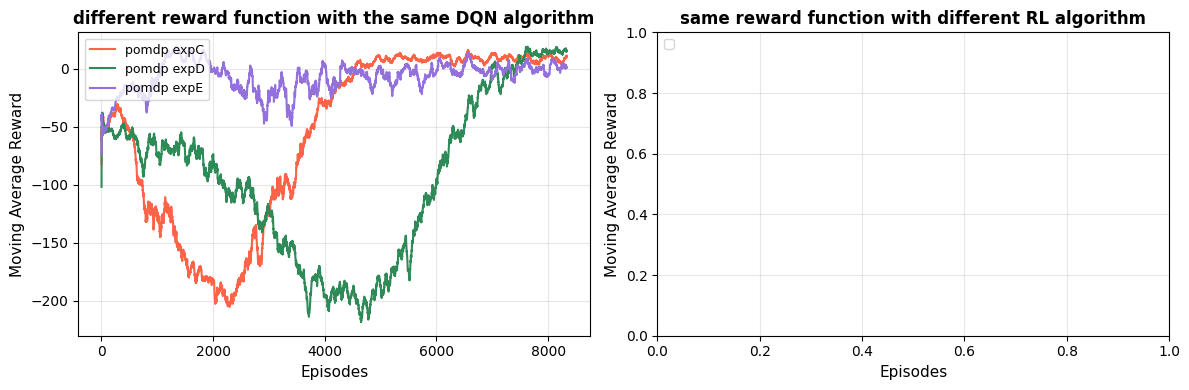

In [25]:
import os
import json
import matplotlib.pyplot as plt

# 统一读取数据
# 1.default single reward function Ta
# DQN
dqn_pomdp_expB_ep_rew_mean_list = []
dqn_pomdp_expB_episodes = []

with open(os.path.join("logs/iseec_lx_v4_mdp_pomdp_expB_DQN_multi_objective_single_T_a_exp822_700000_default", "progress.json"), "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            data = json.loads(line)
        except json.JSONDecodeError:
            continue  # 跳过无法解析的行
        if "rollout/ep_rew_mean" in data and "time/episodes" in data:
            dqn_pomdp_expB_ep_rew_mean_list.append(data["rollout/ep_rew_mean"])
            dqn_pomdp_expB_episodes.append(data["time/episodes"])
                  
DQN_pomdp_expC_ep_rew_mean_list = []
DQN_pomdp_expC_episodes = []  

with open(os.path.join("logs/iseec_lx_v4_mdp_pomdp_expC_partialB_DQN_multi_objective_single_T_a_exp822_700000_default", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                DQN_pomdp_expC_ep_rew_mean_list.append(data["rollout/ep_rew_mean"])
                DQN_pomdp_expC_episodes.append(data["time/episodes"])

DQN_pomdp_expD_ep_rew_mean_list = []
DQN_pomdp_expD_episodes = []  

with open(os.path.join("logs/iseec_lx_v4_mdp_pomdp_expD_nature_DQN_multi_objective_single_T_a_exp822_700000_default", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                DQN_pomdp_expD_ep_rew_mean_list.append(data["rollout/ep_rew_mean"])
                DQN_pomdp_expD_episodes.append(data["time/episodes"])
      
DQN_pomdp_expE_ep_rew_mean_list = []
DQN_pomdp_expE_episodes = []  
          
with open(os.path.join("logs/iseec_lx_v4_mdp_pomdp_expE_socio_DQN_multi_objective_single_T_a_exp822_700000_default", "progress.json"), "r", encoding="utf-8") as f:
    for line in f: # 每一行读取
        if line.strip(): # 确保行不为空
            data = json.loads(line) # 单行的 data 部分
            if "rollout/ep_rew_mean" in data and "time/episodes" in data:
                DQN_pomdp_expE_ep_rew_mean_list.append(data["rollout/ep_rew_mean"])
                DQN_pomdp_expE_episodes.append(data["time/episodes"])

# 绘制各种的 reward 曲线
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1, ax2 = axes

ax1.set_title('different reward function with the same DQN algorithm', fontsize=12, fontweight='bold')
ax2.set_title('same reward function with different RL algorithm', fontsize=12, fontweight='bold')

# ax1.plot(dqn_pomdp_expB_episodes, dqn_pomdp_expB_ep_rew_mean_list, label="pomdp expB", color='royalblue')
ax1.plot(DQN_pomdp_expC_episodes, DQN_pomdp_expC_ep_rew_mean_list, label="pomdp expC", color='tomato')
ax1.plot(DQN_pomdp_expD_episodes, DQN_pomdp_expD_ep_rew_mean_list, label="pomdp expD", color='seagreen')
ax1.plot(DQN_pomdp_expE_episodes, DQN_pomdp_expE_ep_rew_mean_list, label="pomdp expE", color='mediumpurple')

ax1.set_xlabel("Episodes", fontsize=11)
ax1.set_ylabel("Moving Average Reward", fontsize=11)

ax1.legend(loc='upper left', fontsize=9, frameon=True)
ax1.grid(alpha=0.3)

# 统一配置细节
ax1.legend(loc='upper left', fontsize=9, frameon=True)

# ax2.plot(dqn_exp822_episodes, dqn_exp822_ep_rew_mean_list, label="DQN", color= 'royalblue')
# ax2.plot(PPO_exp822_episodes, PPO_exp822_ep_rew_mean_list, label="DQN", color='darkorange')

ax2.set_xlabel("Episodes", fontsize=11)
ax2.set_ylabel("Moving Average Reward", fontsize=11)

ax2.legend(loc='upper left', fontsize=9, frameon=True)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
# plt.savefig(overleaf+'/all_rewards.pdf')


In [26]:
# 绘制不同 model 面对观测的差异性

# 成功结果的示意(在线读取版本)
import sys
import os

from stable_baselines3 import DQN
sys.path.append(os.path.abspath('src'))
from src.envs.iseec_lx_v4_pomdp import IEMEnv
import pandas as pd
import datetime
import numpy as np
from matplotlib.gridspec import GridSpec
import os
import json
import matplotlib.pyplot as plt

def plot_compare_multi_model_action_analysis(total_action=None, total_state=None, env=None):
    """绘制不同 model 操作下的 action 部分
    """
    time_start = 2017
    time_end = time_start + len(total_state)
    time_range = range(time_start, time_end)
    
    total_action = np.array(total_action)
    
    fig = plt.figure(figsize=(16, 18))
    gs = GridSpec(3, 2, figure=fig, height_ratios=[2, 1, 1], hspace=0.4, wspace=0.3)
    
    # 大图（跨2列）- 用散点图
    ax_big = fig.add_subplot(gs[0, :])
    ax_big.scatter(time_range, total_action, label='Macro action over time', color='tab:blue', s=30)
    ax_big.set_title('Action choice')
    ax_big.set_xlabel('t [years]', fontsize=14)
    ax_big.set_ylabel('Chosen Action', fontsize=14)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# 加载不同类型的 model
model_infos = [
    {
        "path": "./model/iseec_lx_v4_mdp_pomdp_expE_socio_DQN_multi_objective_single_T_a_exp822_700000_default",
        "label": "expE_socio"
    },
    {
        "path": "./model/iseec_lx_v4_mdp_pomdp_expD_nature_DQN_multi_objective_single_T_a_exp822_700000_default",
        "label": "expD_nature"
    },
    # 可以继续添加更多模型
]

# 加载对应环境
env = IEMEnv(reward_type="multi_objective_single_T_a_exp822", pomdp_state_indices=[5,6,7,8,9])

# 加载对应模型
model = DQN.load(f"./model/iseec_lx_v4_mdp_pomdp_expE_socio_DQN_multi_objective_single_T_a_exp822_700000_default", env=env)
        
max_steps = 300

all_actions = []

for info in model_infos:
    # 加载环境和模型
    env = IEMEnv(reward_type="multi_objective_single_T_a_exp822")
    model = DQN.load(info["path"], env=env)
    obs, _ = env.reset(use_random_reset=False, seed=42)
    total_action = []
    for i in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info_step = env.step(action)
        action_number, action_name = IEMEnv.action2number_env(action)
        total_action.append(action_number)
        if done:
            break
    all_actions.append((info["label"], total_action))

# 绘制
plt.figure(figsize=(12, 5))
for label, actions in all_actions:
    plt.plot(range(len(actions)), actions, label=label)
plt.xlabel("Step")
plt.ylabel("Action")
plt.title("Action sequence for different models")
plt.legend()
plt.show()
    


[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

ValueError: Observation spaces do not match: Box(-inf, inf, (5,), float64) != Box(-inf, inf, (10,), float64)